# Activation functions and their derivatives

Reference notes for the nonlinearities used in the conv nets in this repo. The
derivative is the interesting half: it is what the gradient gets multiplied by
at every layer during backprop, so its shape decides whether a deep stack trains
or stalls. AlexNet's key departure from earlier nets was exactly this — swapping
the saturating `sigmoid`/`tanh` for the non-saturating `ReLU`.

The figure below pairs **sigmoid with softmax on the top row** (both squash, both
cap the gradient at $0.25$) and keeps `tanh`/`ReLU` on the bottom.

### Sigmoid

$$\sigma(x) = \frac{1}{1 + e^{-x}} \qquad\quad \sigma'(x) = \sigma(x)\,\bigl(1 - \sigma(x)\bigr)$$

Range $(0, 1)$, derivative peaks at $\sigma'(0) = 0.25$. Output is not
zero-centred, and the gradient is $\le \tfrac14$ everywhere — stack a few layers
and it vanishes.

### Tanh

$$\tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}} = 2\,\sigma(2x) - 1 \qquad\quad \tanh'(x) = 1 - \tanh^{2}(x)$$

Range $(-1, 1)$, zero-centred, derivative peaks at $\tanh'(0) = 1$. Better than
sigmoid, but still saturates for $|x| \gtrsim 3$.

### ReLU

$$\mathrm{ReLU}(x) = \max(0, x) \qquad\quad \mathrm{ReLU}'(x) = \begin{cases} 1 & x > 0 \\ 0 & x < 0 \end{cases}$$

Undefined at $x = 0$; implementations pick $0$ (or $1$) by convention. The
gradient is exactly $1$ on the whole positive half-line, so it never shrinks the
signal — this is what let AlexNet train ~6× faster than the tanh equivalent.

### Softmax

The other three are **elementwise**: $f$ maps $\mathbb{R} \to \mathbb{R}$ and the
derivative is one number per unit. Softmax is not — it maps a whole logit vector
to a probability vector, because the denominator couples every component:

$$\mathrm{softmax}(\mathbf{z})_i = s_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \qquad\quad \sum_{i=1}^{K} s_i = 1$$

So it has no single derivative curve — it has a $K \times K$ **Jacobian**:

$$\frac{\partial s_i}{\partial z_j} = s_i\,(\delta_{ij} - s_j) = \begin{cases} s_i\,(1 - s_i) & i = j \quad \text{(diagonal)} \\[2pt] -\,s_i s_j & i \ne j \quad \text{(off-diagonal)} \end{cases}$$

Three consequences, all visible in the plots below:

- **The diagonal is the sigmoid-derivative shape** — $s_i(1-s_i)$, capped at
  $0.25$. Softmax saturates the same way sigmoid does; that is why the two sit
  side by side in the figure.
- **Off-diagonals are negative.** Pushing one logit up pushes every other
  probability down; the classes compete for a fixed budget of $1$.
- **Every row sums to zero**, since $\sum_i s_i = 1$ is constant. The Jacobian is
  singular, which is the same statement as
  $\mathrm{softmax}(\mathbf{z} + c) = \mathrm{softmax}(\mathbf{z})$ — softmax is
  invariant to a constant shift of all logits. That invariance is what makes the
  `z - z.max()` trick safe, and it is the standard fix for `exp` overflow.

For $K = 2$ softmax collapses back to sigmoid: $s_1 = \sigma(z_1 - z_2)$.

In practice you rarely differentiate softmax alone — paired with cross-entropy
the Jacobian telescopes to the much friendlier
$\partial \mathcal{L}/\partial z_i = s_i - y_i$, which is why libraries fuse the
two into one op (`cross_entropy` takes raw logits, not probabilities).

## How the three relate

Sigmoid, tanh and softmax are not three unrelated functions — they are the same
normalized-exponential machinery seen at different $K$ and under different affine
framing. Each relation below is an exact algebraic identity, not an
approximation — equality holds for every $x$.

### 1. Softmax in terms of sigmoid (any $K$)

Split the denominator into "this class" and "everything else", then divide
through by $e^{z_i}$:

$$s_i = \frac{e^{z_i}}{e^{z_i} + \sum_{j \ne i} e^{z_j}} = \frac{1}{1 + \exp\!\Bigl(-\bigl(z_i - \log\sum_{j \ne i} e^{z_j}\bigr)\Bigr)}$$

which is exactly a sigmoid evaluated at a shifted logit:

$$\boxed{\;s_i = \sigma\Bigl(z_i - \mathrm{LSE}_{j \ne i}(\mathbf{z})\Bigr)\;} \qquad \mathrm{LSE}_{j \ne i}(\mathbf{z}) = \log\!\sum_{j \ne i} e^{z_j}$$

**Every softmax component is a sigmoid** — a *one-vs-rest* sigmoid, in which the
$K-1$ competitors are collapsed by log-sum-exp (the smooth max) into a single
opposing logit. Softmax is not a different function from sigmoid; it is sigmoid
applied to "this logit minus the soft-max of the others." This holds for every
$K$, not just $K = 2$.

It also explains the Jacobian's diagonal at a glance: $\mathrm{LSE}_{j \ne i}$ does
not depend on $z_i$, so differentiating $s_i = \sigma(a_i)$ with $a_i = z_i - \mathrm{LSE}_{j\ne i}$
gives $\partial a_i/\partial z_i = 1$ and therefore

$$\frac{\partial s_i}{\partial z_i} = \sigma'(a_i) = s_i(1 - s_i)$$

— the sigmoid derivative, for any $K$.

**Corollary: any pair, conditionally, is a sigmoid.** Restricting attention to two
classes, the shared denominator cancels:

$$\frac{s_i}{s_i + s_j} = \sigma(z_i - z_j) \qquad\Longleftrightarrow\qquad \log\frac{s_i}{s_j} = z_i - z_j$$

The log-odds of any pair is just their logit gap — softmax only ever cares about
differences, which is the shift invariance from earlier, seen pairwise.

**Corollary: $K = 2$ is plain sigmoid.** With a single competitor, $\mathrm{LSE}$
over one term is that term, so the boxed identity collapses to

$$\mathrm{softmax}([z_1, z_2])_1 = \sigma(z_1 - z_2) \qquad\quad \sigma(x) = \mathrm{softmax}([x,\, 0])_1$$

Sigmoid *is* softmax with $K = 2$; the "budget of 1 shared among $K$ classes"
becomes the familiar $p$ and $1 - p$. This is also why a $K$-class head uses
softmax + cross-entropy while a binary head uses sigmoid + BCE: they are the same
loss, written twice.

### 2. Tanh is an affinely rescaled sigmoid

$$\boxed{\;\tanh(x) = 2\,\sigma(2x) - 1\;} \qquad\Longleftrightarrow\qquad \sigma(x) = \tfrac{1}{2}\Bigl(1 + \tanh\tfrac{x}{2}\Bigr)$$

Stretch the input by $2$, stretch the output by $2$, shift down by $1$: the range
$(0,1)$ becomes $(-1,1)$. Same curve, different frame — which is the whole reason
tanh is zero-centred and sigmoid is not.

### 3. Chaining the two ties tanh to softmax

$$\tanh(x) = 2\,\mathrm{softmax}([2x,\, 0])_1 - 1$$

So all three collapse onto one object. Sigmoid is the $K=2$ softmax; tanh is that
same sigmoid, recentred.

### 4. The derivatives inherit the relations exactly

Differentiating relation 2 by the chain rule picks up a factor of $2$ from the
input scaling and another $2$ from the output scaling:

$$\tanh'(x) = 4\,\sigma'(2x)$$

| | $f$ | $f'$ | peak of $f'$ |
|---|---|---|---|
| **sigmoid** | $\sigma(x)$ | $\sigma(1-\sigma)$ | $0.25$ at $x = 0$ |
| **tanh** | $2\sigma(2x) - 1$ | $1 - \tanh^2 = 4\,\sigma'(2x)$ | $1$ at $x = 0$ |
| **softmax** | $s_i$ | $s_i(1 - s_i)$ *(diagonal)* | $0.25$ at $s_i = \tfrac12$ |

That factor of $4$ is the entire story of the figure above: tanh's gradient peaks
exactly $4\times$ higher than sigmoid's, which is why tanh trains better — and why
neither touches ReLU's flat $1$ across the whole positive half-line.

The softmax row matches the sigmoid row by relation 1: the diagonal entry
$s_i(1-s_i)$ *is* $\sigma'$ evaluated at the one-vs-rest logit — for every $K$,
not only $K = 2$.

### 5. All three are gradients of the same potential

The deepest version of the relationship. Softmax is the gradient of
**log-sum-exp**, and sigmoid is the gradient of **softplus**:

$$\mathrm{softmax}(\mathbf{z}) = \nabla_{\mathbf{z}} \log \sum_{j} e^{z_j} \qquad\quad \sigma(x) = \frac{d}{dx} \log\bigl(1 + e^{x}\bigr)$$

And these two potentials are the same function at $K = 2$, closing the loop:

$$\mathrm{logsumexp}([x,\, 0]) = \log\bigl(e^{x} + 1\bigr) = \mathrm{softplus}(x)$$

Log-sum-exp is the smooth maximum, so softmax is literally the gradient of a soft
`max` — the name describes the *argmax* it approximates, not the max itself.

### Inverses

$$\sigma^{-1}(p) = \log\frac{p}{1-p} \quad \text{(the logit)} \qquad\quad \tanh^{-1}(y) = \tfrac{1}{2}\log\frac{1+y}{1-y} = \tfrac{1}{2}\,\sigma^{-1}\!\left(\tfrac{1+y}{2}\right)$$

Softmax has no inverse — it is singular (§ Softmax above), and recovers logits
only up to an additive constant.

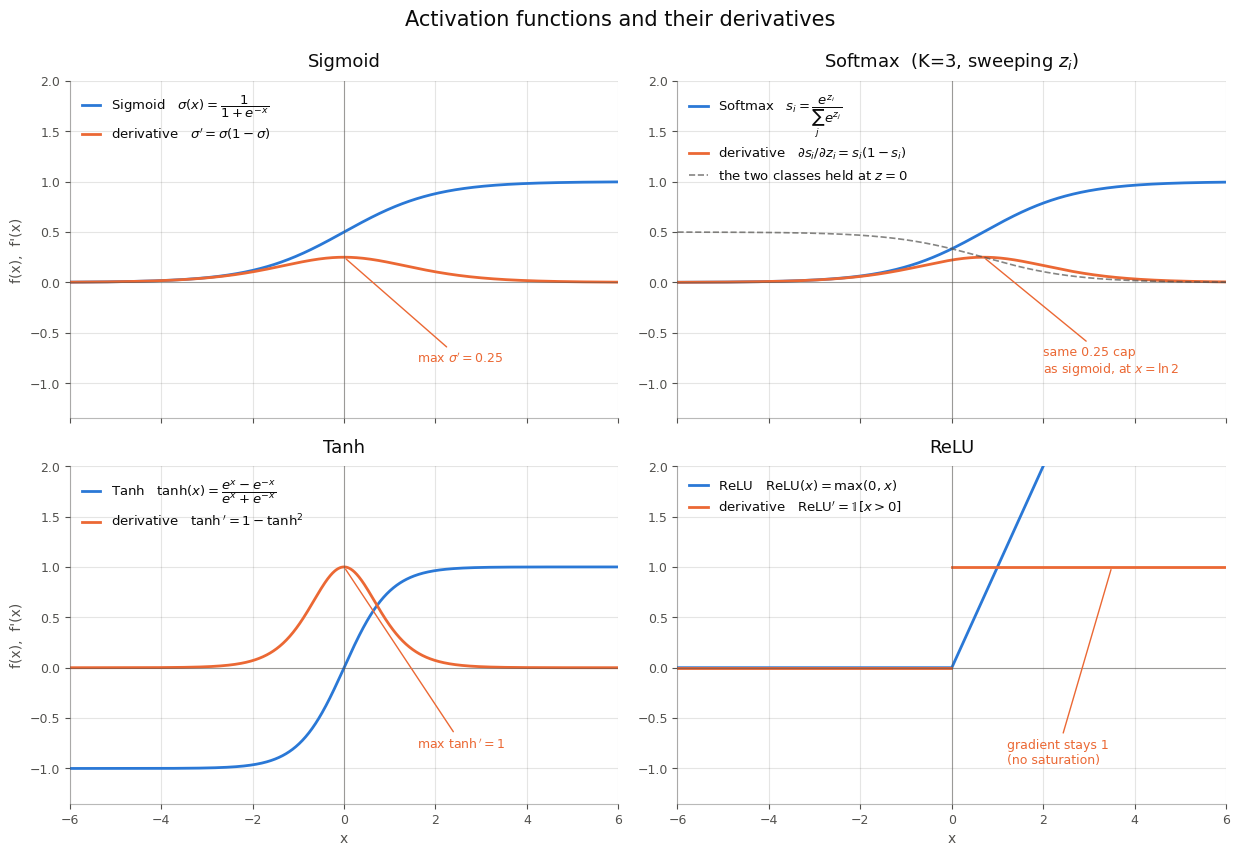

In [1]:
import matplotlib.pyplot as plt
import numpy as np

F_COLOR = "#2a78d6"   # the activation itself
D_COLOR = "#eb6834"   # its derivative
INK, MUTED = "#0b0b0b", "#52514e"

x = np.linspace(-6, 6, 1001)   # odd count so x == 0 is a real sample point

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

d_sigmoid = sigmoid * (1 - sigmoid)
d_tanh = 1 - tanh**2
# undefined at x = 0: mask it so the step is drawn as two segments, not a jump
d_relu = np.where(x > 0, 1.0, np.where(x < 0, 0.0, np.nan))

# softmax is vector -> vector, so there is no single curve. Sweep one logit of a
# 3-class vector z = [x, 0, 0] and watch the probabilities compete.
e = np.exp(x - np.maximum(x, 0))          # shift-invariant: guards exp overflow
e0 = np.exp(0 - np.maximum(x, 0))
denom = e + 2 * e0
s_hot = e / denom                          # the class whose logit we are moving
s_other = e0 / denom                       # the two held at 0 (identical)
d_softmax = s_hot * (1 - s_hot)            # the Jacobian's diagonal entry

# top row pairs sigmoid with softmax: same squashing, same 0.25 gradient cap.
# bottom row is the two elementwise alternatives.
panels = [
    (sigmoid, d_sigmoid, "Sigmoid",
     r"$\sigma(x)=\dfrac{1}{1+e^{-x}}$", r"$\sigma'=\sigma(1-\sigma)$", None),
    (s_hot, d_softmax, r"Softmax  (K=3, sweeping $z_i$)",
     r"$s_i=\dfrac{e^{z_i}}{\sum_j e^{z_j}}$",
     r"$\partial s_i/\partial z_i=s_i(1-s_i)$", s_other),
    (tanh, d_tanh, "Tanh",
     r"$\tanh(x)=\dfrac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$", r"$\tanh'=1-\tanh^{2}$", None),
    (relu, d_relu, "ReLU",
     r"$\mathrm{ReLU}(x)=\max(0,x)$", r"$\mathrm{ReLU}'=\mathbb{1}[x>0]$", None),
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.6), sharex=True)
axes = axes.ravel()

for ax, (f, df, name, eq_f, eq_d, extra) in zip(axes, panels):
    ax.plot(x, f, color=F_COLOR, lw=2, label=f"{name.split()[0]}   {eq_f}")
    ax.plot(x, df, color=D_COLOR, lw=2, label=f"derivative   {eq_d}")
    if extra is not None:
        # recessive channel: the competing classes, not a third categorical hue
        ax.plot(x, extra, color=MUTED, lw=1.2, ls="--", alpha=0.7,
                label=r"the two classes held at $z=0$")

    ax.axhline(0, color=MUTED, lw=0.8, alpha=0.5)
    ax.axvline(0, color=MUTED, lw=0.8, alpha=0.5)
    ax.grid(True, color=MUTED, alpha=0.15, lw=0.8)

    ax.set_title(name, color=INK, fontsize=13, pad=10)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-1.35, 2.0)
    ax.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(MUTED)
        ax.spines[side].set_alpha(0.4)

    ax.legend(loc="upper left", frameon=False, fontsize=9.5,
              labelcolor=INK, handlelength=1.4)

# peak gradient is the whole point - label it directly
axes[0].annotate(r"max $\sigma'=0.25$", xy=(0, 0.25), xytext=(1.6, -0.8),
                 color=D_COLOR, fontsize=9,
                 arrowprops=dict(arrowstyle="-", color=D_COLOR, lw=1))
axes[1].annotate("same 0.25 cap\nas sigmoid, at $x=\\ln 2$",
                 xy=(x[np.argmax(d_softmax)], 0.25), xytext=(2.0, -0.9),
                 color=D_COLOR, fontsize=9,
                 arrowprops=dict(arrowstyle="-", color=D_COLOR, lw=1))
axes[2].annotate(r"max $\tanh'=1$", xy=(0, 1.0), xytext=(1.6, -0.8),
                 color=D_COLOR, fontsize=9,
                 arrowprops=dict(arrowstyle="-", color=D_COLOR, lw=1))
axes[3].annotate("gradient stays 1\n(no saturation)", xy=(3.5, 1.0), xytext=(1.2, -0.95),
                 color=D_COLOR, fontsize=9,
                 arrowprops=dict(arrowstyle="-", color=D_COLOR, lw=1))

for ax in axes[2:]:
    ax.set_xlabel("x", color=MUTED)
for ax in (axes[0], axes[2]):
    ax.set_ylabel("f(x),  f'(x)", color=MUTED)

fig.suptitle("Activation functions and their derivatives", color=INK,
             fontsize=15, y=0.99)
fig.tight_layout()
plt.show()

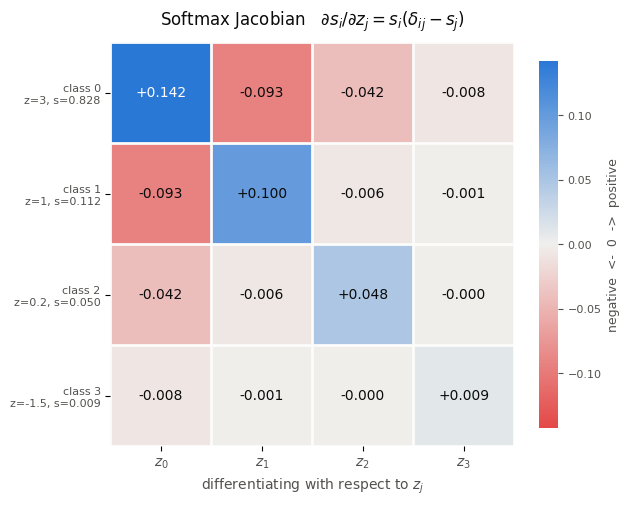

probabilities s : [0.8283 0.1121 0.0504 0.0092]  sum = 0.9999999999999999
row sums of J   : [0. 0. 0. 0.]   <- all zero: J is singular
diagonal        : [0.1422 0.0995 0.0478 0.0091]  = s(1-s), max possible 0.25


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# The full softmax Jacobian for one concrete logit vector.
# Diverging data (sign carries meaning) -> two poles + a neutral gray midpoint.
DIV = LinearSegmentedColormap.from_list("blue_gray_red",
                                        ["#e34948", "#f0efec", "#2a78d6"])
INK, MUTED = "#0b0b0b", "#52514e"


def softmax(z):
    z = np.asarray(z, dtype=float)
    e = np.exp(z - z.max())        # shift invariance: softmax(z + c) == softmax(z)
    return e / e.sum()


def softmax_jacobian(s):
    """J[i, j] = s_i (delta_ij - s_j) = diag(s) - s s^T"""
    return np.diag(s) - np.outer(s, s)


z = np.array([3.0, 1.0, 0.2, -1.5])
s = softmax(z)
J = softmax_jacobian(s)

K = len(z)
lim = np.abs(J).max()             # symmetric about 0 so the neutral midpoint sits at 0

fig, ax = plt.subplots(figsize=(6.4, 5.4))
im = ax.imshow(J, cmap=DIV, vmin=-lim, vmax=lim)

# value in every cell: sign and magnitude never rest on color alone
for i in range(K):
    for j in range(K):
        shade = DIV((J[i, j] + lim) / (2 * lim))[:3]
        lum = 0.2126 * shade[0] + 0.7152 * shade[1] + 0.0722 * shade[2]
        ax.text(j, i, f"{J[i, j]:+.3f}", ha="center", va="center", fontsize=10,
                color="#ffffff" if lum < 0.5 else INK)

labels = [f"class {i}\nz={z[i]:g}, s={s[i]:.3f}" for i in range(K)]
ax.set_xticks(range(K), [f"$z_{i}$" for i in range(K)], color=MUTED)
ax.set_yticks(range(K), labels, fontsize=8, color=MUTED)
ax.set_xlabel(r"differentiating with respect to $z_j$", color=MUTED)
ax.set_title(r"Softmax Jacobian   $\partial s_i/\partial z_j = s_i(\delta_{ij}-s_j)$",
             color=INK, fontsize=12, pad=12)
ax.set_xticks(np.arange(K + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(K + 1) - 0.5, minor=True)
ax.grid(which="minor", color="#fcfcfb", lw=2)   # 2px surface gap between cells
ax.tick_params(which="minor", length=0)
for side in ax.spines.values():
    side.set_visible(False)

cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("negative  <-  0  ->  positive", color=MUTED, fontsize=9)
cbar.ax.tick_params(colors=MUTED, labelsize=8)
cbar.outline.set_visible(False)

fig.tight_layout()
plt.show()

print("probabilities s :", np.round(s, 4), " sum =", s.sum())
print("row sums of J   :", np.round(J.sum(axis=1), 12), "  <- all zero: J is singular")
print("diagonal        :", np.round(np.diag(J), 4), " = s(1-s), max possible 0.25")